Notebook to test methane forcing by OH from the GFDL model. 

Test:
1. perturbation form of methane vs. changing the lifetime of methane directly
2. how to parameterize the exogenous forcing by OH (aka the scaling factor to relate v/v to Tg methane/yr (ppb methane/yr))
3. (maybe) tropical vs. global OH

Units:
OH is given in v/v in the GFDL model. For ease, I will convert the reaction rate from [Burkholder et al.](https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf) from cm<sup>-3</sup> molec<sup>-1</sup> s<sup>-1</sup> to v/v year<sup>-1</sup>, from which either the lifetime deviations or the methane tendency can be calculated. This will require an assumption of mean temperature at which the reaction occurs.


In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant
)
from methane_noise_forcing.noise import solve_ch4_onebox, solve_ch4_anomaly_lifetime
from methane_noise_forcing.core import FirnFilter
plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["two_column_large"]  # inches
ax_height = 1.5  # inches

In [3]:
# read in OH forcing data
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="config", overrides=["+firn_kernel=firn_model_wais"])

ds = xr.open_dataset(Path(cfg.paths.data_dir) / "oh_forcing" / "oh_forcing.nc")
# extract OH
da_oh_mean = ds["OH"].mean(dim="time")
da_oh_anomaly = ds["OH"] - da_oh_mean
da_oh_anomaly_fraction = da_oh_anomaly / da_oh_mean

In [4]:
# import firn filter for later
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)

In [5]:
# choose appropriate selection
column = "free_trop"
region = "tropical"

oh_mean = da_oh_mean.sel(region=region, column=column).values.item()
oh_anomaly = da_oh_anomaly.sel(region=region, column=column)
oh_anomaly_fraction = da_oh_anomaly_fraction.sel(region=region, column=column)

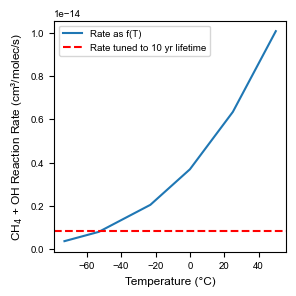

In [6]:
## tune reaction rate such that mean lifetime of ch4 is 10 years
mean_lifetime = 10 # years

k_ch4_oh = 1 / mean_lifetime / oh_mean # (mol rxn / mol air)^-1 yr^-1

## compare rate constant with empirical
## placeholder for now: Alex's pre-computed conversion with number density of air
#  need to eventually change to use temperature and pressure to scale for sensitivity
n_air = 2.69e19 # Rough: number density of air ((molec air / cm3) / mol air)
s_per_year = 24 * 60 * 60 * 365.25 # s/yr

k_converted = k_ch4_oh / s_per_year / n_air # cm3/molec/s

def k_ch4_oh_func(temp):
    """
    Reaction rate of CH4 + OH

    temperature in K, rate in cm3/molec/s
    """
    k = 2.8e-14 * (temp**0.667) * np.exp(-1575 / temp)
    return k

temperatures = np.array([200, 220, 250, 273, 298, 323])  # K
k_as_f_of_temps = k_ch4_oh_func(temperatures)  # cm3/molec/s

fig, ax = plt.subplots(figsize=(3,3))

ax.plot(temperatures - 273, k_as_f_of_temps, label="Rate as f(T)")
ax.axhline(k_converted, color='r', linestyle='--', label=f"Rate tuned to {mean_lifetime} yr lifetime")

ax.set_ylabel("CH$_4$ + OH Reaction Rate (cm³/molec/s)")
ax.set_xlabel("Temperature (°C)")
ax.legend()

# full mass balance form

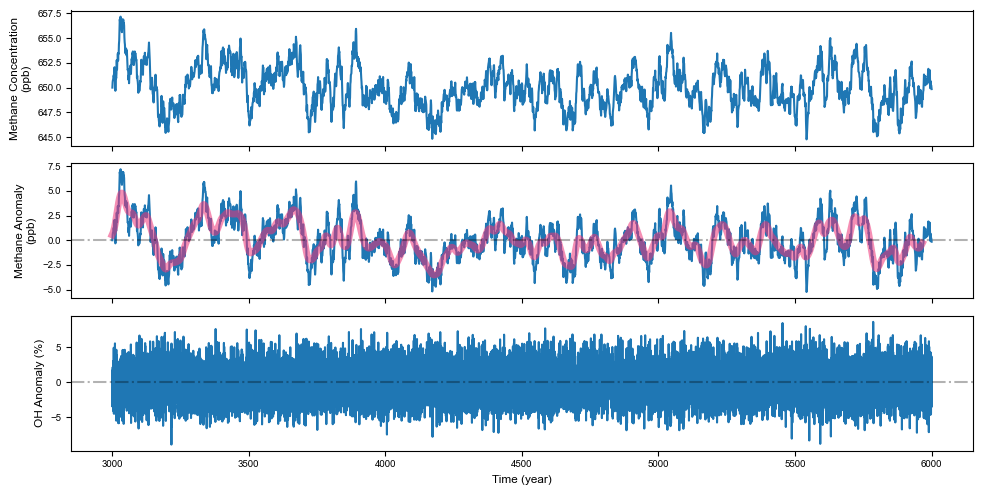

In [7]:
ch4_mean = 650 # ppb
# solve for S_ch4 in terms of ppb / year
S_ch4 = ch4_mean * k_ch4_oh * oh_mean # ppb / year
OH_over_time = (oh_anomaly.time.values, oh_anomaly.values + oh_mean)
t_eval = np.arange(3001, 6002, 1) # years
instantaneous_offset = 35 # years

result_full_mb = solve_ch4_onebox( # all units are mol/mol
    t_eval=t_eval,
    C0=ch4_mean * 1e-9,
    S=S_ch4 * 1e-9,  
    k=k_ch4_oh, # (mol rxn / mol air)^-1 yr^-1
    OH=OH_over_time, # (mol rxn / mol air)
    max_step=0.1, # year
)

## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(3, 1, figsize=(fig_width*1.4, 5), sharex=True)

# top plot: full methane concentration
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

axs[0].plot(result_full_mb.t[time_mask], result_full_mb.C[time_mask] * 1e9, label="Methane Concentration")
axs[0].set_ylabel("Methane Concentration\n(ppb)")

# middle plot: methane anomaly
methane_anomaly_plot = result_full_mb.C - ch4_mean * 1e-9
methane_anomaly_plot_smoothed = firn_filter.apply(
    methane_anomaly_plot,
    dt_series=np.mean(np.diff(t_eval))
)
axs[1].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_full_mb.t >= time_min_plot + instantaneous_offset) & (result_full_mb.t <= time_max_plot + instantaneous_offset)
axs[1].plot(result_full_mb.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[2].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[2].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[2].set_ylabel("OH Anomaly (%)")
axs[2].set_xlabel("Time (year)")

plt.tight_layout()

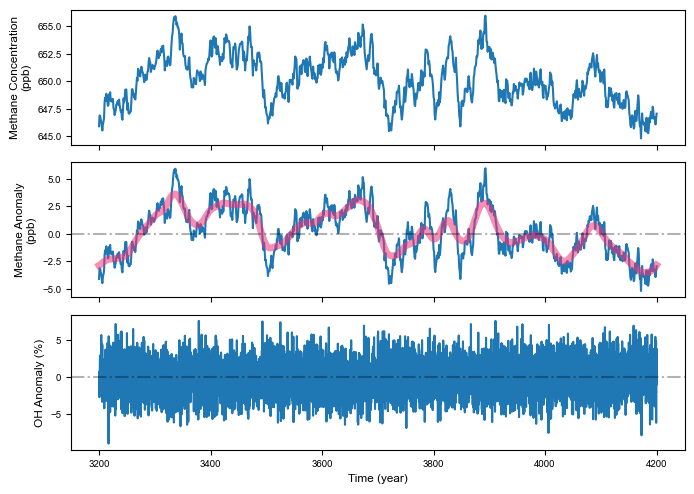

In [8]:
# zoomed in plot
time_min_plot = 3200
time_max_plot = 4200
fig, axs = plt.subplots(3, 1, figsize=(fig_width, 5), sharex=True)

# top plot: full methane concentration
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

axs[0].plot(result_full_mb.t[time_mask], result_full_mb.C[time_mask] * 1e9, label="Methane Concentration")
axs[0].set_ylabel("Methane Concentration\n(ppb)")

# middle plot: methane anomaly
methane_anomaly_plot = result_full_mb.C - ch4_mean * 1e-9
methane_anomaly_plot_smoothed = firn_filter.apply(
    methane_anomaly_plot,
    dt_series=np.mean(np.diff(t_eval))
)
axs[1].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_full_mb.t >= time_min_plot + instantaneous_offset) & (result_full_mb.t <= time_max_plot + instantaneous_offset)
axs[1].plot(result_full_mb.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[2].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[2].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[2].set_ylabel("OH Anomaly (%)")
axs[2].set_xlabel("Time (year)")

plt.tight_layout()

# perturbation form

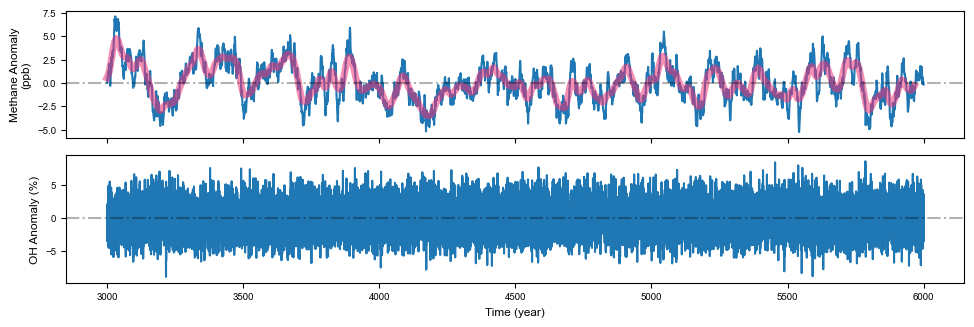

In [9]:
ch4_mean = 650 # ppb
# solve for source/sink anomaly in terms of ppb/year
rate_mean = ch4_mean * k_ch4_oh * oh_mean # ppb / year
S_anom = -1 * rate_mean * (oh_anomaly_fraction) # ppb / year
t_eval = np.arange(3001, 6002, 1) # years
instantaneous_offset = 35 # years 

result_anomaly = solve_ch4_anomaly_lifetime(
    t_eval=t_eval,
    C0_anom=0,
    S_anom=(S_anom.time.values, S_anom.values * 1e-9),
    tau=mean_lifetime,
    max_step=0.1, # year
)

## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(2, 1, figsize=(fig_width*1.4, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
methane_anomaly_plot_smoothed = firn_filter.apply(
    result_anomaly.C,
    dt_series=np.mean(np.diff(t_eval))
)
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_anomaly.t >= time_min_plot + instantaneous_offset) & (result_anomaly.t <= time_max_plot + instantaneous_offset)
axs[0].plot(result_anomaly.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Anomaly (%)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()

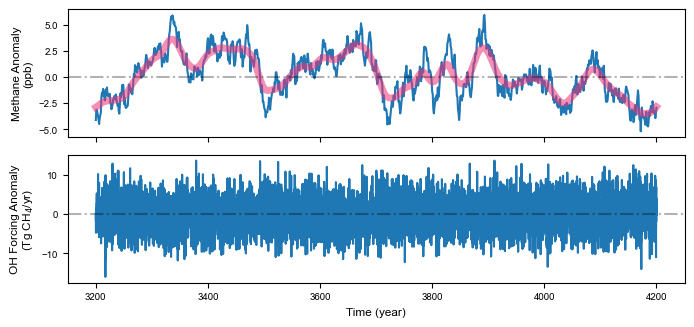

In [10]:
## zoomed in plot
time_min_plot = 3200
time_max_plot = 4200
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
methane_anomaly_plot_smoothed = firn_filter.apply(
    result_anomaly.C,
    dt_series=np.mean(np.diff(t_eval))
)
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_anomaly.t >= time_min_plot + instantaneous_offset) & (result_anomaly.t <= time_max_plot + instantaneous_offset)
axs[0].plot(result_anomaly.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(S_anom.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            S_anom.sel(time=slice(time_min_plot, time_max_plot)).values * -2.75, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Forcing Anomaly\n(Tg CH$_4$/yr)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()

## compare full model to perturbation form

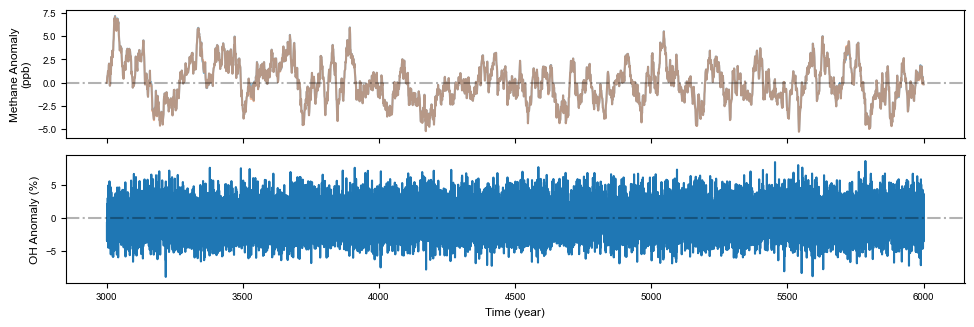

In [11]:
## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(2, 1, figsize=(fig_width*1.4, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
axs[0].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            color=colors_vibrant["blue"],
            alpha=0.5,
            label="full")
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            color=colors_vibrant["orange"],
            alpha=0.5,
            label="perturbation")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Anomaly (%)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()